# 📉 Salifort Motors: Employee Retention Intelligence
> **Project Overview:** Building a predictive system to reduce turnover and optimize human capital.

---

## 📌 1. Business Scenario & Problem Formulation

**Salifort Motors** is currently facing a significant challenge with **employee attrition**. High turnover is creating a substantial financial and operational burden on the company due to:
* 💸 **Recruitment Costs:** High expenses in sourcing and selection.
* ⏱️ **Operational Lag:** Time-consuming interviewing and onboarding processes.
* 🧠 **Knowledge Loss:** Loss of institutional knowledge and team synergy.

The Human Resources (HR) department has curated a comprehensive dataset to investigate the underlying factors driving this trend. As a lead data analyst, the goal is to transform this raw data into **actionable business intelligence**.

---

## 🎯 Primary Objective
To develop a robust **predictive machine learning model** that accurately identifies employees at a high risk of leaving the company before they resign.

---

## 🚀 Strategic Business Goals

| Goal | Description |
| :--- | :--- |
| **Predictive Insight** | Identify at-risk employees with high precision to allow for proactive retention. |
| **Root Cause Analysis** | Pinpoint organizational drivers like **Workload**, **Satisfaction**, and **Tenure**. |
| **Actionable Strategy** | Provide executive-level recommendations to improve retention and reduce losses. |

---

## 📂 2. Data Auditing & Variable Profiling

The dataset consists of **14,999 records** across **10 key organizational features**. Preliminary data profiling was conducted to ensure feature definitions align with the business objectives.

### **Feature Definitions**

| Variable | Type | Description |
|:---|:---|:---|
| **satisfaction_level** | Numeric | Employee-reported job satisfaction level [0–1] |
| **last_evaluation** | Numeric | Score of employee's last performance review [0–1] |
| **number_project** | Discrete | Number of projects assigned to the employee |
| **average_monthly_hours**| Numeric | Average number of hours worked per month |
| **time_spend_company** | Discrete | Total years of tenure with the organization |
| **Work_accident** | Binary | Indicates if the employee experienced an on-site accident |
| **left** | Binary | **Target:** 1 if the employee left the company, 0 otherwise |
| **promotion_last_5years**| Binary | Indicates if a promotion was awarded in the last 5 years |
| **Department** | Categorical| Organizational unit (Sales, HR, IT, etc.) |
| **salary** | Categorical| Relative salary tier (Low, Medium, High) |

---

### 📈 3.1 Project Stakeholders & Business Context
The primary stakeholders for this project are the **Salifort Motors HR Leadership Team** and **Departmental Managers**. 

**The Challenge:** High employee turnover is impacting organizational stability and increasing operational costs (recruitment, onboarding, and training). 
[cite_start]**The Goal:** To leverage data analytics and predictive modeling to identify the root causes of attrition and provide data-driven recommendations to improve long-term retention[cite: 1, 2].

### ⚖️ 3.2 Data Ethics & Privacy
In accordance with professional data standards, the following ethical considerations were applied:
* **Anonymization:** All employee records are de-identified to protect individual privacy.
* **Algorithmic Bias:** The model will be audited to ensure that predictions do not unfairly target specific departments or salary tiers.
* [cite_start]**Transparency:** Insights are intended for organizational improvement (e.g., reducing overwork) rather than punitive measures against individual employees[cite: 1, 2].

### 🔍 3.3 Initial Data Profiling & Observations
Upon initial inspection of the Salifort Motors dataset:
* [cite_start]**Scope:** 14,999 employee records with 10 features.
* **Balance:** We must investigate the balance of the `left` (target) variable to determine if oversampling/undersampling is required.
* [cite_start]**Outliers:** Preliminary scans suggest high variance in `average_monthly_hours`, which may be a primary driver of turnover.

## 🛠️ 1. Environment Setup & Data Acquisition
> **Purpose:** Initialize the analytical environment by importing essential libraries and loading the organizational dataset for auditing.

---

### 1.1 Library Imports
We leverage standard data science libraries for manipulation, visualization, and statistical modeling.

In [1]:
# Import packages

# For data manipulation
import numpy as np
import pandas as pd

# For data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For displaying all of the columns in dataframes
pd.set_option('display.max_columns', None)

# For data modeling
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from xgboost import plot_importance

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# For metrics and helpful functions
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score,\
f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.tree import plot_tree

# For saving models
import pickle

### 1.2 Load dataset

In [2]:
# Load dataset into a dataframe
df0 = pd.read_csv("../data/HR_capstone_dataset.csv")

# Display first few rows of the dataframe
df0.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


# 🔍 2. Data Auditing & Preprocessing
> **Objective:** Perform a rigorous audit of the dataset to ensure data integrity, handle anomalies, and prepare features for statistical modeling.

---

### 2.1 Structural Analysis & Variable Understanding
Before performing cleaning, we evaluate the data types and distributions of the 10 organizational features to ensure they align with their business definitions. 

This stage involves checking:
* **Shape & Size:** Understanding the volume of records we are processing.
* **Schema Validation:** Ensuring each column is stored in the correct technical format (e.g., float vs integer).

### 2.2 Data Integrity & Quality Control
To maintain model reliability and ensure the "Garbage In, Garbage Out" principle does not apply, we execute the following quality checks:

* **Missing Value Analysis:** Verifying that no data is absent, which would require imputation or removal.
* **Redundancy Audit:** Identifying and removing duplicate records that could artificially bias the model's accuracy.
* **Outlier Detection:** Investigating extreme values in `average_monthly_hours` and `time_spend_company` using IQR (Interquartile Range) analysis to determine if they are valid entries or data entry errors.

In [3]:
# Gather basic information about the data
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


### Gather descriptive statistics about the data

In [4]:
# Gather descriptive statistics about the data
df0.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


### Renaming columns

As a data cleaning step, rename the columns as needed. Standardize the column names so that they are all in `snake_case`, correct any column names that are misspelled, and make column names more concise as needed.

In [5]:
# Display all column names
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [6]:
# Rename columns as needed
df0 = df0.rename(columns={'Work_accident': 'work_accident',
                          'average_montly_hours': 'average_monthly_hours',
                          'time_spend_company': 'tenure',
                          'Department': 'department'})

# Display all column names after the update
df0.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_monthly_hours', 'tenure', 'work_accident', 'left',
       'promotion_last_5years', 'department', 'salary'],
      dtype='object')

### Checking missing values

Checking for any missing values in the data.

In [7]:
# Check for missing values
df0.isna().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_monthly_hours    0
tenure                   0
work_accident            0
left                     0
promotion_last_5years    0
department               0
salary                   0
dtype: int64

There are no missing values in the data.

### Checking duplicates

Checking for any duplicate entries in the data.

In [8]:
# Check for duplicates
df0.duplicated().sum()

np.int64(3008)

3,008 rows contain duplicates. That is 20% of the data.

In [9]:
# Inspect some rows containing duplicates as needed

df0[df0.duplicated()].head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
396,0.46,0.57,2,139,3,0,1,0,sales,low
866,0.41,0.46,2,128,3,0,1,0,accounting,low
1317,0.37,0.51,2,127,3,0,1,0,sales,medium
1368,0.41,0.52,2,132,3,0,1,0,RandD,low
1461,0.42,0.53,2,142,3,0,1,0,sales,low


The output above shows the first five rows that are duplicated elsewhere in the dataset. Given that the data contains multiple continuous variables across several columns, it is highly unlikely that two employees would report identical values for every feature. Therefore, these duplicated records are unlikely to be legitimate and are removed from the dataset.

In [10]:
# Drop duplicates and save resulting dataframe in a new variable as needed

df1 = df0.drop_duplicates(keep='first')

# Display first few rows of new dataframe as needed
df1.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


### Checking outliers

Checking for outliers in the data.

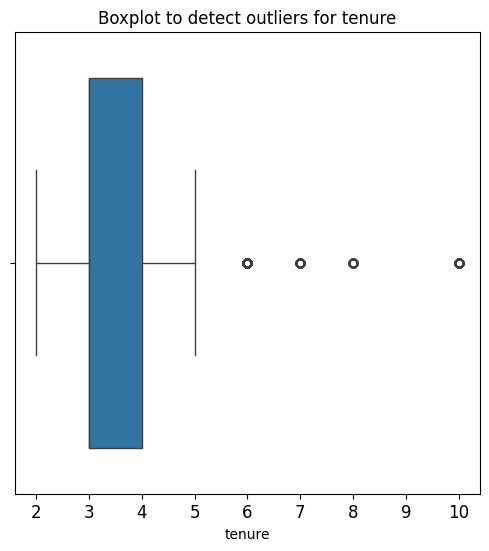

In [11]:
# Create a boxplot to visualize distribution of `tenure` and detect any outliers
plt.figure(figsize=(6,6))
plt.title('Boxplot to detect outliers for tenure', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
sns.boxplot(x=df1['tenure'])
plt.show()

The boxplot above indicates the presence of outliers in the tenure variable. To better understand their impact, the next step is to examine how many observations in the dataset contain outlier values for this feature.

In [12]:
# Determine the number of rows containing outliers 


# Compute the 25th percentile value in `tenure`
percentile25 = df1['tenure'].quantile(0.25)

# Compute the 75th percentile value in `tenure`
percentile75 = df1['tenure'].quantile(0.75)

# Compute the interquartile range in `tenure`
iqr = percentile75 - percentile25

# Define the upper limit and lower limit for non-outlier values in `tenure`
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr
print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)

# Identify subset of data containing outliers in `tenure`
outliers = df1[(df1['tenure'] > upper_limit) | (df1['tenure'] < lower_limit)]

# Count how many rows in the data contain outliers in `tenure`
print("Number of rows in the data containing outliers in `tenure`:", len(outliers))

Lower limit: 1.5
Upper limit: 5.5
Number of rows in the data containing outliers in `tenure`: 824


Certain types of models are more sensitive to outliers than others. When you get to the stage of building your model, consider whether to remove these outliers based on the type of model you decide to use.

# Analyze Stage: Exploratory Data Analysis (EDA)

In this stage, we perform exploratory data analysis to examine relationships between variables, understand data distributions, and identify patterns relevant to employee attrition.

Key aspects considered during this analysis include:

- Relationships between variables and their impact on employee turnover  
- Distribution of numerical and categorical features  
- Data transformations applied and the rationale behind them  
- The role of EDA in preparing data for predictive modeling  
- Tools and resources used during the analysis  
- Ethical considerations related to data interpretation and modeling

---

# Data Exploration

We begin by examining employee attrition:

- Determine the total number of employees who left the company  
- Calculate the percentage of employees who left relative to the overall workforce  

This initial exploration provides a baseline understanding of the target variable and guides further analysis.

In [13]:
# Get numbers of people who left vs. stayed

print(df1['left'].value_counts())
print()

# Get percentages of people who left vs. stayed

print(df1['left'].value_counts(normalize=True))

left
0    10000
1     1991
Name: count, dtype: int64

left
0    0.833959
1    0.166041
Name: proportion, dtype: float64


### Data visualizations

Next, we explore variables of interest through visualizations to better understand relationships within the data.

A good starting point is a **stacked boxplot** showing the distribution of `average_monthly_hours` across `number_project`, comparing employees who stayed versus those who left. Boxplots are effective for visualizing distributions, but they can be misleading if sample sizes are not considered.

To complement the boxplot, a **stacked histogram** can be created to visualize the distribution of `number_project` for employees who stayed and those who left, providing additional context on the underlying sample sizes.

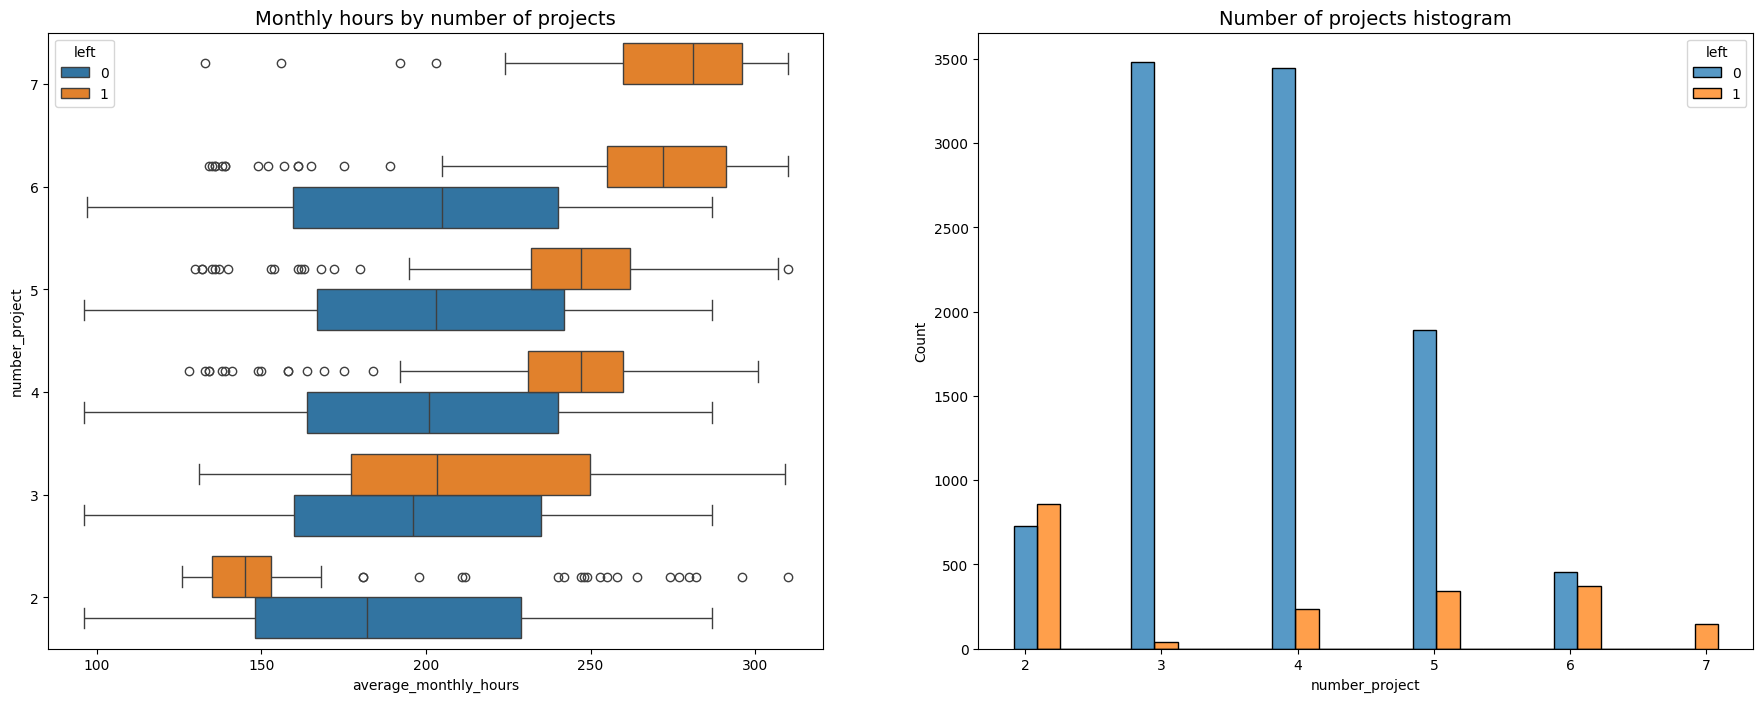

In [14]:
# Create a plot as needed 


# Set figure and axes
fig, ax = plt.subplots(1, 2, figsize = (22,8))

# Create boxplot showing `average_monthly_hours` distributions for `number_project`, comparing employees who stayed versus those who left
sns.boxplot(data=df1, x='average_monthly_hours', y='number_project', hue='left', orient="h", ax=ax[0])
ax[0].invert_yaxis()
ax[0].set_title('Monthly hours by number of projects', fontsize='14')

# Create histogram showing distribution of `number_project`, comparing employees who stayed versus those who left
tenure_stay = df1[df1['left']==0]['number_project']
tenure_left = df1[df1['left']==1]['number_project']
sns.histplot(data=df1, x='number_project', hue='left', multiple='dodge', shrink=2, ax=ax[1])
ax[1].set_title('Number of projects histogram', fontsize='14')

# Display the plots
plt.show()

It is natural to expect that employees working on more projects would also work longer hours, and this trend is evident in the data: the mean `average_monthly_hours` increases with `number_project` for both employees who stayed and those who left. However, several patterns stand out:

- **Employees who left the company can be grouped into two categories:**
  1. Those who worked considerably fewer hours than peers with the same number of projects. This group may include employees who were fired or who had already given notice and were assigned fewer hours.
  2. Those who worked significantly more hours than peers. These employees likely quit voluntarily and may have been major contributors to the projects they worked on.

- All employees handling **seven projects** left the company. The interquartile range for this group, as well as for those who left with six projects, is approximately 255–295 hours/month—substantially higher than other groups.

- The data suggests that the **optimal number of projects** for employees is **3–4**, as the ratio of employees who left versus those who stayed is lowest in this cohort.

- Assuming a standard work week of 40 hours and two weeks of vacation per year, the expected average monthly working hours for a Monday–Friday schedule is approximately **166.7 hours/month**. Except for employees working on two projects, every group—even those who stayed—worked well above this benchmark, indicating that employees may be overworked.

The next step in the analysis is to confirm that all employees with seven projects indeed left the company.


In [15]:
# Get value counts of stayed/left for employees with 7 projects
df1[df1['number_project']==7]['left'].value_counts()

left
1    145
Name: count, dtype: int64

This confirms that all employees handling seven projects left the company.

The next analysis examines the relationship between `average_monthly_hours` and employee `satisfaction_level`.


Text(0.5, 1.0, 'Monthly hours by last evaluation score')

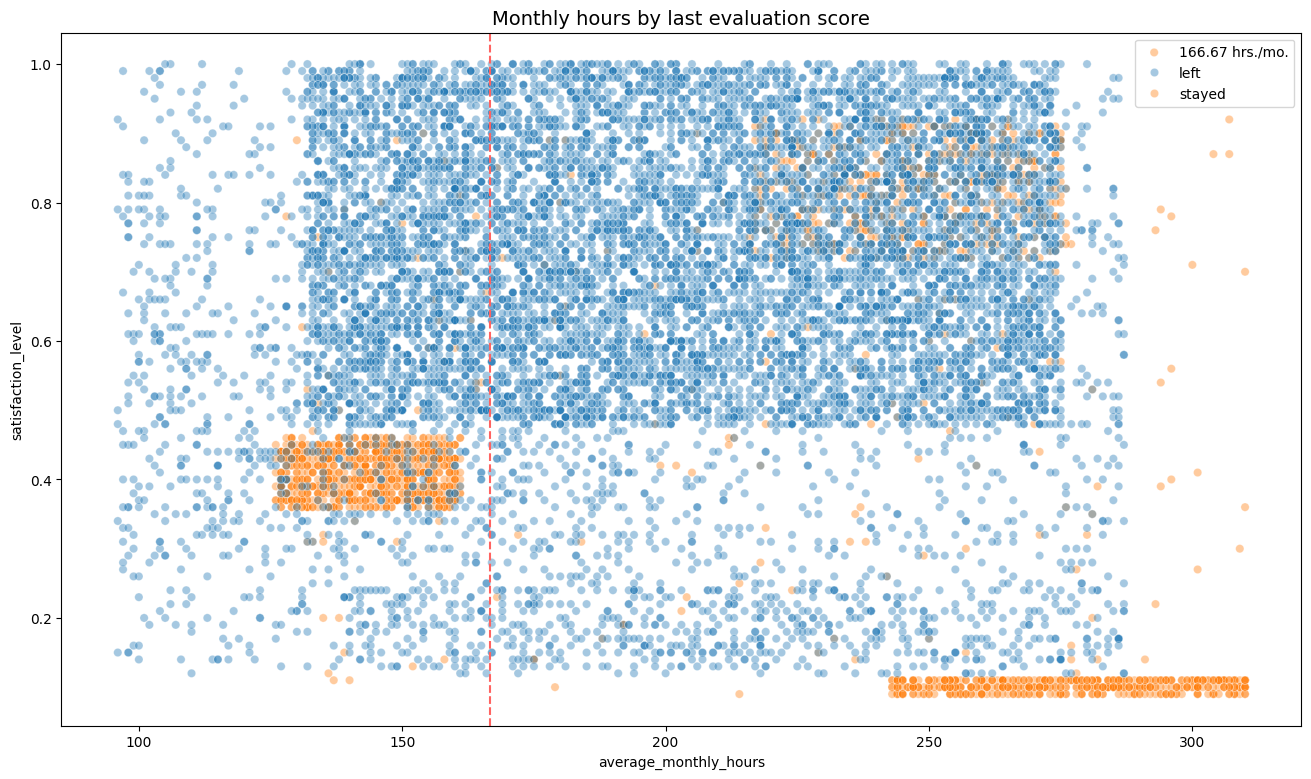

In [16]:
# Scatterplot of `average_monthly_hours` versus `satisfaction_level`, 
# comparing employees who stayed versus those who left

plt.figure(figsize=(16, 9))
sns.scatterplot(data=df1, x='average_monthly_hours', y='satisfaction_level', hue='left', alpha=0.4)

# Add a reference line for standard monthly hours (166.67 hrs/month)
plt.axvline(x=166.67, color='#ff6361', label='166.67 hrs./mo.', ls='--')

plt.legend(labels=['166.67 hrs./mo.', 'left', 'stayed'])
plt.title('Monthly hours by last evaluation score', fontsize=14)


The scatterplot above reveals several notable patterns:

- A sizeable group of employees worked approximately **240–315 hours per month**. At 315 hours per month, this corresponds to over 75 hours per week for an entire year. These extreme work hours likely contributed to their **very low satisfaction levels** (close to zero).

- Another group of employees who left had more typical working hours, around **normal ranges**, yet their satisfaction was only about 0.4. While the exact reasons for their departure are unclear, it is possible that **peer pressure or perceived workload** contributed to reduced satisfaction.

- A third group worked approximately **210–280 hours per month**, with satisfaction levels ranging from **0.7 to 0.9**, indicating that moderate workloads may be associated with higher satisfaction.

- The unusual shape of these distributions may indicate **data anomalies**, such as data manipulation or synthetic data.


The next visualization examines the relationship between employee `satisfaction_level` and `tenure`.


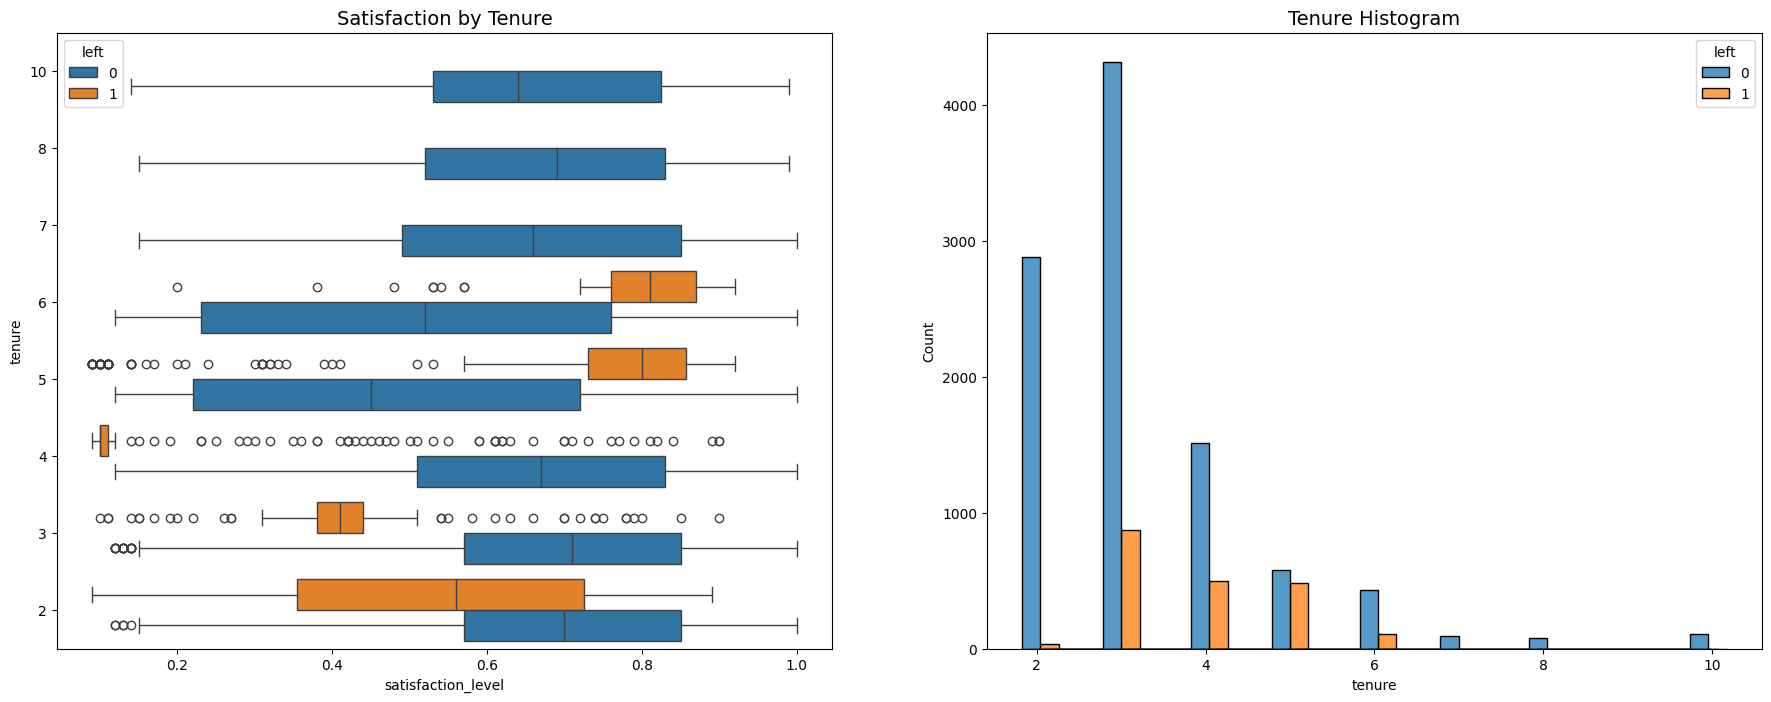

In [17]:
# Set up figure with two subplots
fig, ax = plt.subplots(1, 2, figsize=(22, 8))

# Boxplot of `satisfaction_level` by `tenure`, comparing employees who stayed versus those who left
sns.boxplot(data=df1, x='satisfaction_level', y='tenure', hue='left', orient="h", ax=ax[0])
ax[0].invert_yaxis()
ax[0].set_title('Satisfaction by Tenure', fontsize=14)

# Histogram of `tenure`, comparing employees who stayed versus those who left
tenure_stay = df1[df1['left'] == 0]['tenure']
tenure_left = df1[df1['left'] == 1]['tenure']
sns.histplot(data=df1, x='tenure', hue='left', multiple='dodge', shrink=5, ax=ax[1])
ax[1].set_title('Tenure Histogram', fontsize=14)

plt.show()


The plots above reveal several insights:

- Employees who left the company generally fall into two groups: **dissatisfied employees with shorter tenures** and **very satisfied employees with medium-length tenures**.  
- Employees with approximately **four years of tenure** who left show unusually low satisfaction levels. This may indicate changes in company policy or other factors affecting employees specifically at the four-year mark.  
- The longest-tenured employees did not leave, and their satisfaction levels were similar to those of newer employees who stayed.  
- The histogram shows relatively few long-tenured employees, which could indicate that these are higher-ranking, higher-paid positions.

The next step in the analysis is to calculate the **mean and median satisfaction scores** for employees who left versus those who stayed.


In [18]:
# Calculate the mean and median satisfaction scores for employees who left versus those who stayed
df1.groupby(['left'])['satisfaction_level'].agg([np.mean, np.median])


C:\Users\Jalil\AppData\Local\Temp\ipykernel_11372\1136509811.py:2: FutureWarning: The provided callable <function mean at 0x00000176B9DA7A60> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df1.groupby(['left'])['satisfaction_level'].agg([np.mean, np.median])
C:\Users\Jalil\AppData\Local\Temp\ipykernel_11372\1136509811.py:2: FutureWarning: The provided callable <function median at 0x00000176B9ED9A80> is currently using SeriesGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  df1.groupby(['left'])['satisfaction_level'].agg([np.mean, np.median])


,mean,median
left,,
0,0.667365,0.69
1,0.440271,0.41


As expected, the mean and median satisfaction scores of employees who left are lower than those of employees who stayed. Interestingly, for employees who stayed, the mean satisfaction score is slightly below the median, suggesting that satisfaction levels among this group may be **left-skewed**.

The next analysis examines **salary levels across different tenures**.


Text(0.5, 1.0, 'Salary Histogram by Tenure: Long-Tenured Employees')

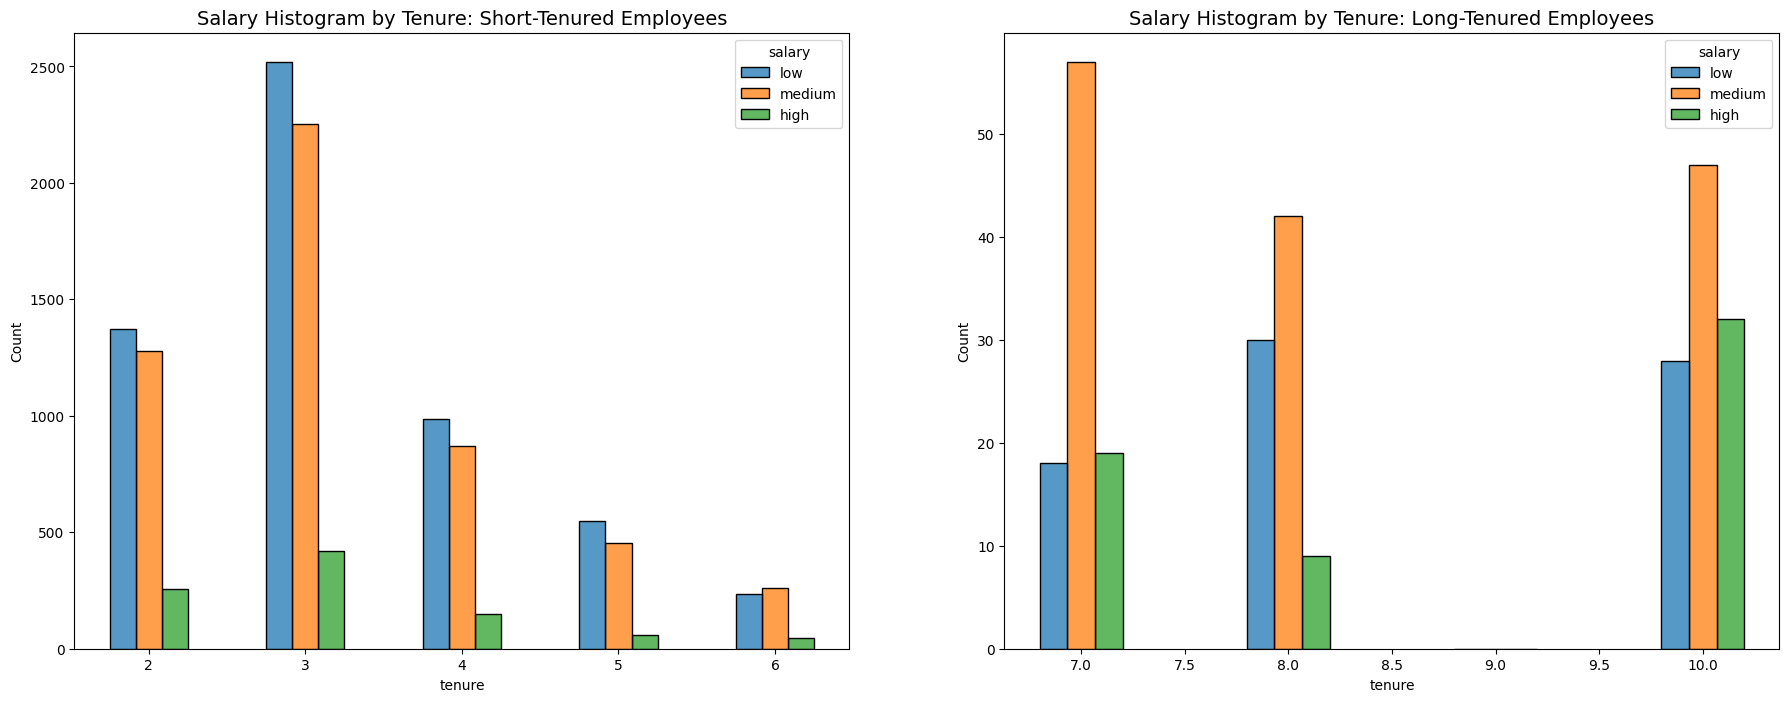

In [19]:
# Set up figure with two subplots
fig, ax = plt.subplots(1, 2, figsize=(22, 8))

# Separate employees by tenure
tenure_short = df1[df1['tenure'] < 7]  # Short-tenured employees
tenure_long = df1[df1['tenure'] > 6]   # Long-tenured employees

# Histogram of salary distribution for short-tenured employees
sns.histplot(
    data=tenure_short, 
    x='tenure', 
    hue='salary', 
    discrete=1, 
    hue_order=['low', 'medium', 'high'], 
    multiple='dodge', 
    shrink=0.5, 
    ax=ax[0]
)
ax[0].set_title('Salary Histogram by Tenure: Short-Tenured Employees', fontsize=14)

# Histogram of salary distribution for long-tenured employees
sns.histplot(
    data=tenure_long, 
    x='tenure', 
    hue='salary', 
    discrete=1, 
    hue_order=['low', 'medium', 'high'], 
    multiple='dodge', 
    shrink=0.4, 
    ax=ax[1]
)
ax[1].set_title('Salary Histogram by Tenure: Long-Tenured Employees', fontsize=14)


The plots above indicate that long-tenured employees are **not disproportionately represented by higher-paid employees**.

The next analysis examines the relationship between working long hours and receiving high evaluation scores. A **scatterplot of `average_monthly_hours` versus `last_evaluation`** will help visualize this relationship.


Text(0.5, 1.0, 'Monthly Hours by Last Evaluation Score')

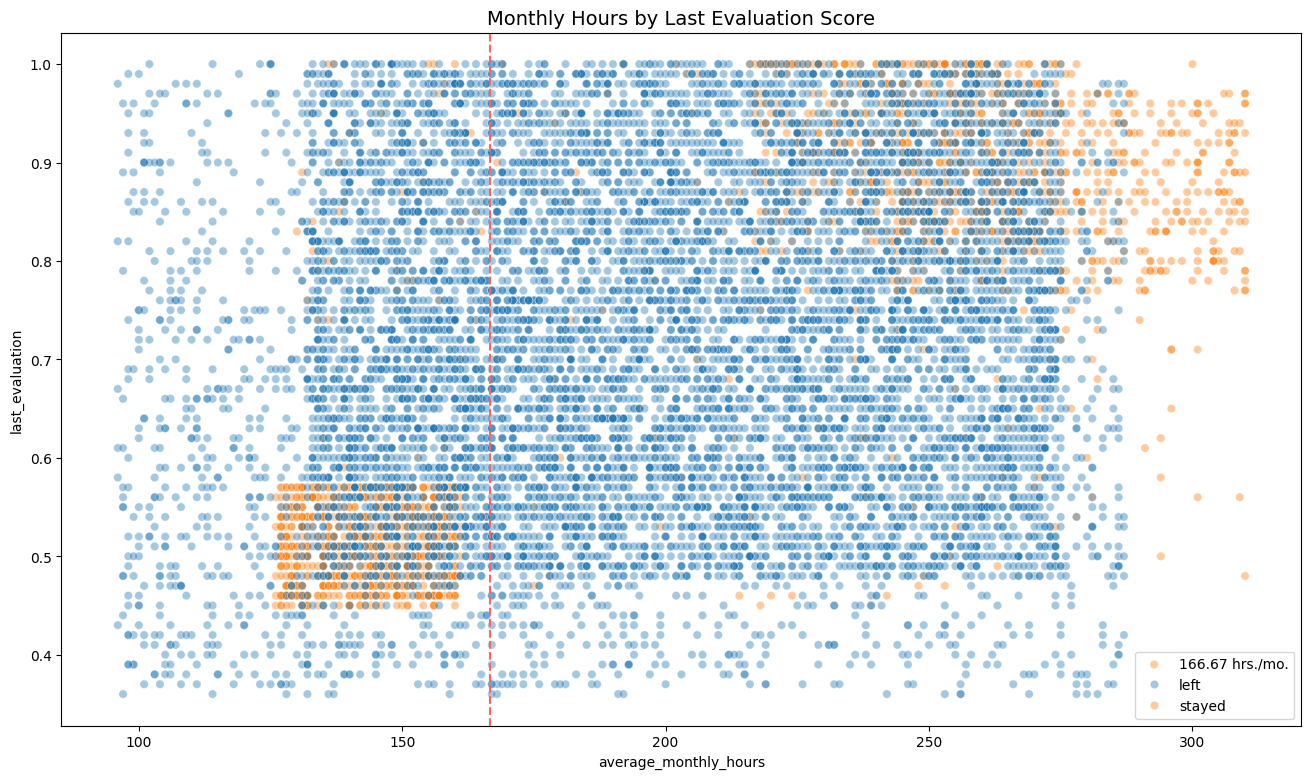

In [20]:
# Scatterplot of `average_monthly_hours` versus `last_evaluation`, 
# comparing employees who stayed versus those who left

plt.figure(figsize=(16, 9))
sns.scatterplot(data=df1, x='average_monthly_hours', y='last_evaluation', hue='left', alpha=0.4)

# Reference line for standard monthly hours (166.67 hrs/month)
plt.axvline(x=166.67, color='#ff6361', label='166.67 hrs./mo.', ls='--')

plt.legend(labels=['166.67 hrs./mo.', 'left', 'stayed'])
plt.title('Monthly Hours by Last Evaluation Score', fontsize=14)


The scatterplot above reveals several insights:

- Employees who left the company fall into two groups: **overworked employees with high evaluation scores** and **employees working slightly below the nominal monthly average of 166.67 hours with lower evaluation scores**.  
- There appears to be a positive relationship between **hours worked** and **evaluation score**, although it is not absolute.  
- Few employees fall in the upper-left quadrant of the plot, indicating that **working long hours does not guarantee a high evaluation score**.  
- Most employees in the company work well over **167 hours per month**, suggesting a generally high workload.

The next step in the analysis is to investigate whether employees who worked very long hours were **promoted in the last five years**.


Text(0.5, 1.0, 'Monthly Hours by Promotion in Last 5 Years')

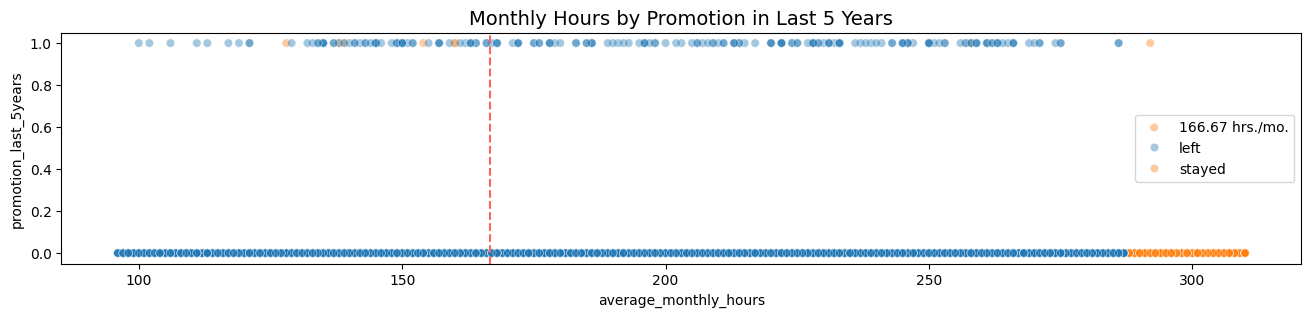

In [21]:
# Scatterplot of `average_monthly_hours` versus `promotion_last_5years`,
# comparing employees who stayed versus those who left

plt.figure(figsize=(16, 3))
sns.scatterplot(data=df1, x='average_monthly_hours', y='promotion_last_5years', hue='left', alpha=0.4)

# Reference line for standard monthly hours (166.67 hrs/month)
plt.axvline(x=166.67, color='#ff6361', ls='--')

plt.legend(labels=['166.67 hrs./mo.', 'left', 'stayed'])
plt.title('Monthly Hours by Promotion in Last 5 Years', fontsize=14)


The scatterplot above highlights several observations:

- Very few employees who were **promoted in the last five years** left the company.  
- Very few employees who worked the **longest hours** received promotions.  
- All employees who left were among those working the **longest hours**.

The next step in the analysis is to examine how employees who left are **distributed across departments**.


In [22]:
# Display counts for each department
df1["department"].value_counts()

department
sales          3239
technical      2244
support        1821
IT              976
RandD           694
product_mng     686
marketing       673
accounting      621
hr              601
management      436
Name: count, dtype: int64

Text(0.5, 1.0, 'Counts of Employees Stayed vs Left by Department')

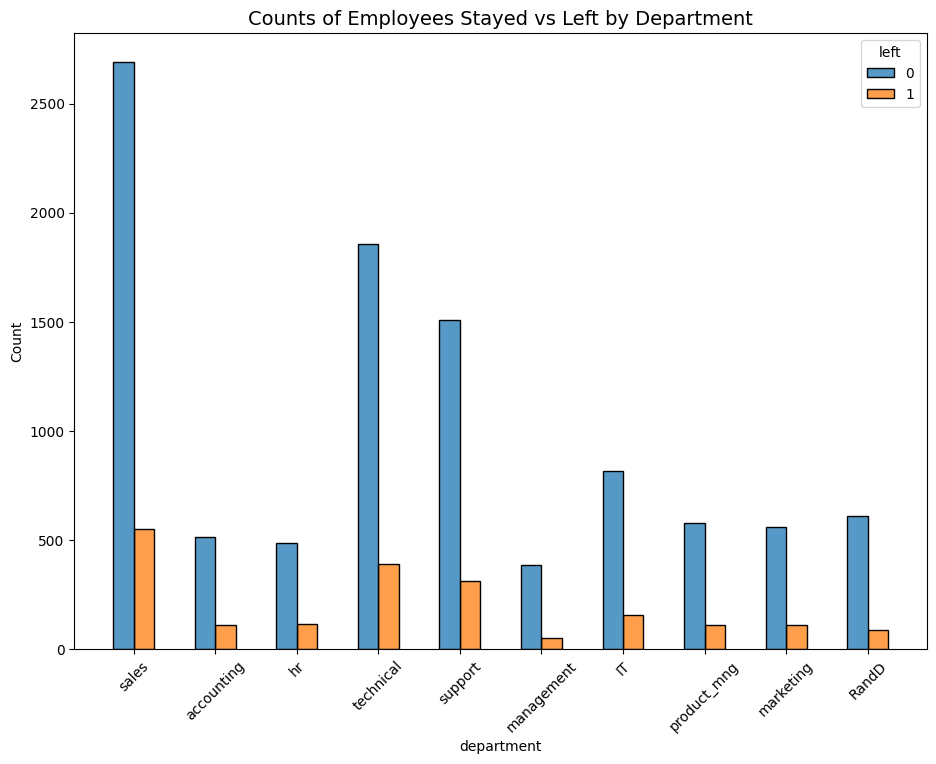

In [23]:
# Stacked histogram comparing department distribution of employees who left versus those who stayed

plt.figure(figsize=(11, 8))
sns.histplot(
    data=df1, 
    x='department', 
    hue='left', 
    discrete=1, 
    hue_order=[0, 1], 
    multiple='dodge', 
    shrink=0.5
)
plt.xticks(rotation=45)
plt.title('Counts of Employees Stayed vs Left by Department', fontsize=14)


The histogram above shows that no single department stands out as having a significantly different proportion of employees who left compared to those who stayed.

The final step in this stage is to examine **strong correlations between variables** in the dataset.


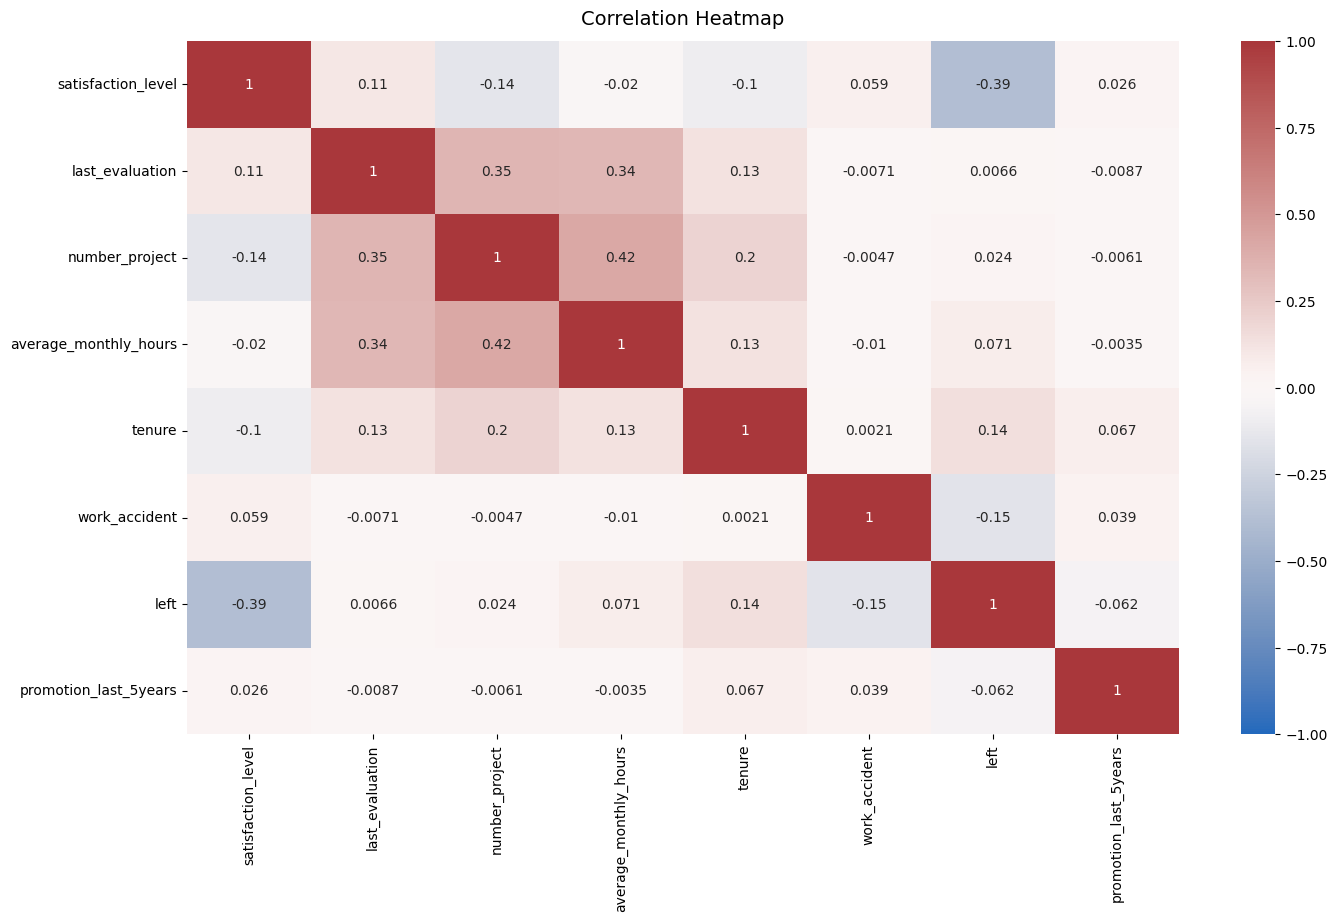

In [24]:
# Correlation heatmap of numerical variables only
plt.figure(figsize=(16, 9))

# Select only numeric columns for correlation
numeric_df = df0.select_dtypes(include=np.number)

heatmap = sns.heatmap(
    numeric_df.corr(), 
    vmin=-1, 
    vmax=1, 
    annot=True, 
    cmap=sns.color_palette("vlag", as_cmap=True)
)
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':14}, pad=12)
plt.show()


The correlation heatmap reveals several key relationships:

- **Number of projects**, **average monthly hours**, and **last evaluation scores** are positively correlated with each other.  
- **Employee attrition (`left`)** is negatively correlated with **satisfaction level**, indicating that lower satisfaction is associated with a higher likelihood of leaving.


### Insights

The analysis suggests that employee attrition may be influenced by **management and workload factors**. Key observations include:

- Leaving the company is associated with **longer working hours**, **handling many projects**, and **lower satisfaction levels**.  
- Employees working long hours without receiving promotions or high evaluation scores may experience **burnout**.  
- There is a substantial group of employees who appear to be **overworked and at risk of burnout**.  
- Employees with more than **six years of tenure** tend to remain at the company, indicating higher retention among longer-tenured staff.


# Step 3. Model Building, Step 4. Results and Evaluation

The objective of this stage is to build a predictive model to determine whether an employee is likely to leave the company. Since the outcome variable `left` is **binary** (0 = stayed, 1 = left), this is a **binary classification task**.

## Data Preparation

Before modeling, non-numeric variables need to be encoded:

- **Department:** Categorical variable → converted to **dummy variables** for modeling.  
- **Salary:** Ordinal variable → converted to numeric levels (0 = low, 1 = medium, 2 = high) to preserve the natural hierarchy.

This ensures all predictor variables are numeric and suitable for logistic regression.

## Logistic Regression Modeling

A **binomial logistic regression model** is appropriate for this task because it handles binary outcomes and provides interpretable coefficients. The logistic regression model predicts the probability that an employee leaves the company based on selected independent variables.

### Model Assumptions

The logistic regression model relies on the following assumptions:

- The outcome variable is categorical  
- Observations are independent  
- No severe multicollinearity among predictors  
- No extreme outliers  
- Linear relationship between each predictor and the logit of the outcome  
- Sufficiently large sample size  

These assumptions are evaluated before fitting the model to ensure the reliability and interpretability of the results.

## Next Steps

The dataset is prepared, and the assumptions are checked. The next steps involve:

1. Splitting the data into training and testing sets  
2. Fitting the logistic regression model  
3. Evaluating model performance using metrics such as accuracy, precision, recall, and the ROC curve  
4. Interpreting model coefficients to understand the effect of each variable on employee attrition


In [25]:
# Create a copy of the dataframe for encoding
df_enc = df1.copy()

# Encode the 'salary' column as an ordinal numeric variable
# 0 = low, 1 = medium, 2 = high
df_enc['salary'] = (
    df_enc['salary'].astype('category')
    .cat.set_categories(['low', 'medium', 'high'])
    .cat.codes
)

# Dummy encode the 'department' column (one-hot encoding)
df_enc = pd.get_dummies(df_enc, drop_first=False)

# Display the first few rows of the encoded dataframe
df_enc.head()


,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False
1,0.80,0.86,5,262,6,0,1,0,1,False,False,False,False,False,False,False,True,False,False
2,0.11,0.88,7,272,4,0,1,0,1,False,False,False,False,False,False,False,True,False,False
3,0.72,0.87,5,223,5,0,1,0,0,False,False,False,False,False,False,False,True,False,False
4,0.37,0.52,2,159,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False


Next, a **correlation heatmap** is created to visualize the relationships between numeric variables.  
This helps identify which variables are strongly correlated and may be important predictors in the model.


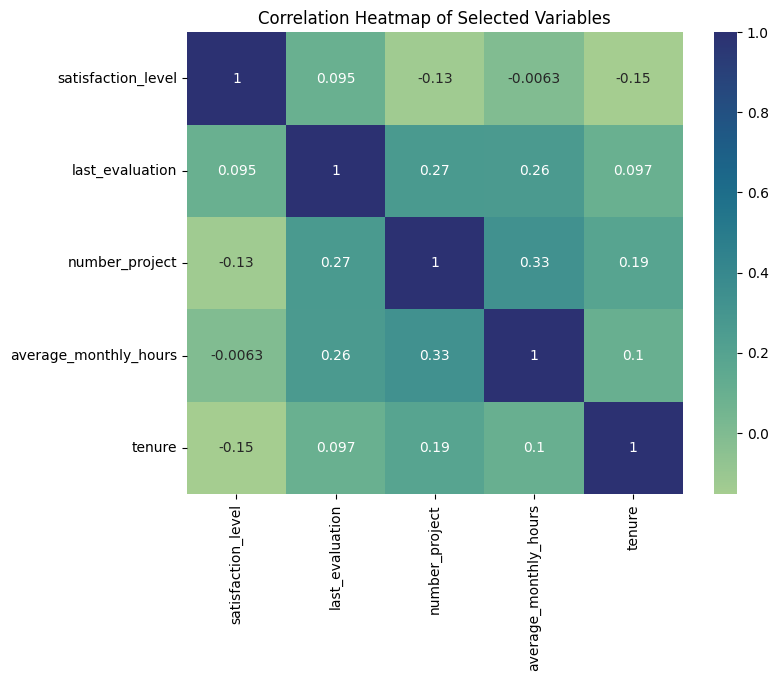

In [26]:
# Correlation heatmap of selected numeric variables
# This visualizes how strongly the predictors are related to each other

plt.figure(figsize=(8, 6))
sns.heatmap(
    df_enc[['satisfaction_level', 'last_evaluation', 'number_project', 
            'average_monthly_hours', 'tenure']].corr(),
    annot=True,
    cmap="crest"
)
plt.title('Correlation Heatmap of Selected Variables')
plt.show()


Next, a **stacked bar plot** is created to compare the number of employees across departments,  
distinguishing between those who left and those who stayed.  
This visualization highlights whether any department has a higher proportion of attrition.


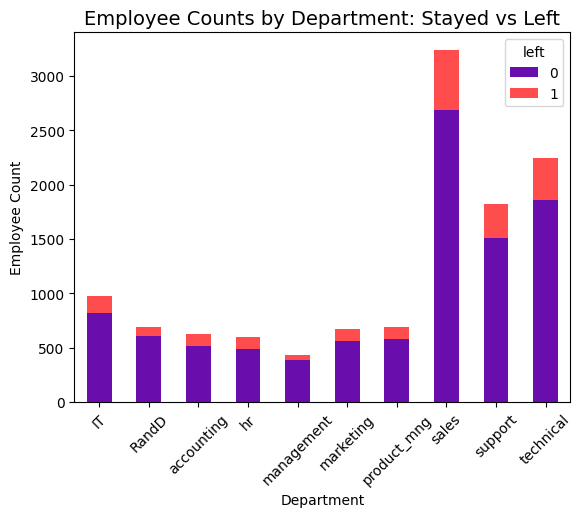

In [27]:
# Stacked bar plot showing the number of employees in each department
# Comparison between employees who stayed (0) and those who left (1)
# Purple bars = stayed, red bars = left

pd.crosstab(df1['department'], df1['left']).plot(
    kind='bar',
    color=['#6a0dad', '#ff4c4c'],  # Purple for stayed, red for left
    stacked=True
)

plt.title('Employee Counts by Department: Stayed vs Left', fontsize=14)
plt.ylabel('Employee Count')
plt.xlabel('Department')
plt.xticks(rotation=45)
plt.show()


Since logistic regression is sensitive to outliers, the next step is to **remove the outliers in the `tenure` column** identified earlier.  
This ensures that extreme values do not disproportionately influence the model coefficients and improves model stability.


In [28]:
# Remove outliers in the 'tenure' column to improve logistic regression performance
# Only keep rows where 'tenure' is within the previously defined lower and upper limits
df_logreg = df_enc[(df_enc['tenure'] >= lower_limit) & (df_enc['tenure'] <= upper_limit)]

# Display the first few rows of the cleaned dataframe
df_logreg.head()


,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False
2,0.11,0.88,7,272,4,0,1,0,1,False,False,False,False,False,False,False,True,False,False
3,0.72,0.87,5,223,5,0,1,0,0,False,False,False,False,False,False,False,True,False,False
4,0.37,0.52,2,159,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False
5,0.41,0.50,2,153,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False


Next, the **outcome variable** (`left`) is isolated.  
This is the target variable that the logistic regression model will predict.

In [29]:
# Isolate the outcome variable for modeling
# 'left' is the target variable that the model will predict
y = df_logreg['left']

# Display the first few rows of the target variable
y.head()


0    1
2    1
3    1
4    1
5    1
Name: left, dtype: int64

Next, the **predictor variables** (`X`) are selected.  
These are the features that the logistic regression model will use to predict whether an employee leaves the company.


In [30]:
# Select predictor variables for the logistic regression model
# All columns except 'left' are used as features
X = df_logreg.drop('left', axis=1)

# Display the first few rows of the feature set
X.head()


,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,0,0,False,False,False,False,False,False,False,True,False,False
2,0.11,0.88,7,272,4,0,0,1,False,False,False,False,False,False,False,True,False,False
3,0.72,0.87,5,223,5,0,0,0,False,False,False,False,False,False,False,True,False,False
4,0.37,0.52,2,159,3,0,0,0,False,False,False,False,False,False,False,True,False,False
5,0.41,0.50,2,153,3,0,0,0,False,False,False,False,False,False,False,True,False,False


The dataset is split into **training and testing sets** to evaluate the model's performance.  
Since the target variable (`left`) is imbalanced, **stratified sampling** is used to ensure the class distribution is preserved in both sets.


In [31]:
# Split the data into training and testing sets
# Stratify by 'y' to preserve class distribution due to imbalance
# 25% of the data is used for testing, and a fixed random state ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)


A **logistic regression model** is constructed and fitted to the training dataset.  
This model will learn the relationship between the predictor variables and the probability that an employee leaves the company.


In [32]:
# Construct and fit a logistic regression model to the training data
# random_state ensures reproducibility, max_iter increased to ensure convergence
log_clf = LogisticRegression(random_state=42, max_iter=500).fit(X_train, y_train)


C:\Users\Jalil\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


The fitted logistic regression model is used to **make predictions on the test dataset**.  
This allows us to evaluate how well the model generalizes to unseen data.


In [33]:
# Generate predictions on the test set using the trained logistic regression model
# These predictions will be used to evaluate the model's performance
y_pred = log_clf.predict(X_test)


A **confusion matrix** is created to visualize the performance of the logistic regression model.  
It shows the number of correct and incorrect predictions for each class, helping assess how well the model distinguishes between employees who stayed and those who left.


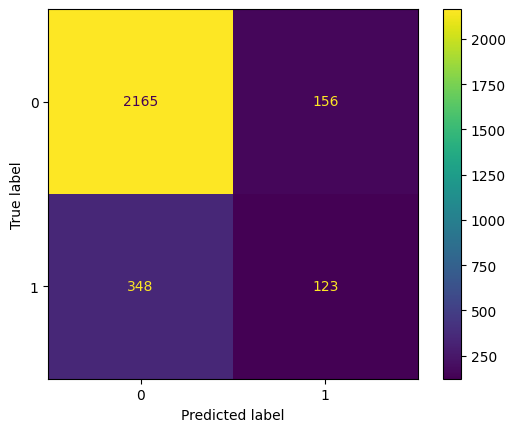

In [34]:
# Compute the confusion matrix for the test set predictions
log_cm = confusion_matrix(y_test, y_pred, labels=log_clf.classes_)

# Create a visual display of the confusion matrix
log_disp = ConfusionMatrixDisplay(confusion_matrix=log_cm, 
                                  display_labels=log_clf.classes_)

# Plot the confusion matrix
# This shows the counts of true positives, true negatives, false positives, and false negatives
log_disp.plot(values_format='')

# Display the plot
plt.show()


The confusion matrix shows the classification performance of the model:

- **True Negatives (TN, upper-left):** Employees who stayed and were correctly predicted as staying.  
- **False Positives (FP, upper-right):** Employees who stayed but were incorrectly predicted as leaving.  
- **False Negatives (FN, bottom-left):** Employees who left but were incorrectly predicted as staying.  
- **True Positives (TP, bottom-right):** Employees who left and were correctly predicted as leaving.  

A perfect model would have only **true positives and true negatives**, with no false positives or false negatives.


A **classification report** is generated to evaluate the performance of the logistic regression model.  
It includes metrics such as **precision**, **recall**, **F1-score**, and **accuracy**, which provide a comprehensive view of how well the model predicts employees leaving versus staying.


Before evaluating model performance, it is important to **check the class balance** of the target variable (`left`).  
Since this is a binary classification task, understanding how many employees stayed versus left helps interpret accuracy and other performance metrics correctly.


In [35]:
# Check the class balance of the target variable 'left'
# Using normalized value counts to see the proportion of each class
df_logreg['left'].value_counts(normalize=True)


left
0    0.831468
1    0.168532
Name: proportion, dtype: float64

The target variable `left` has an approximate **83%-17% split** between employees who stayed and those who left.  

While the classes are not perfectly balanced, the imbalance is not severe.  
If the imbalance were more extreme, resampling techniques could be considered to balance the classes.  
In this case, the current class distribution is acceptable, and we can proceed with evaluating the model.


In [36]:
# Generate a classification report for the logistic regression model
# This includes precision, recall, F1-score, and accuracy for each class
target_names = ['Predicted would not leave', 'Predicted would leave']
print(classification_report(y_test, y_pred, target_names=target_names))


                           precision    recall  f1-score   support

Predicted would not leave       0.86      0.93      0.90      2321
    Predicted would leave       0.44      0.26      0.33       471

                 accuracy                           0.82      2792
                macro avg       0.65      0.60      0.61      2792
             weighted avg       0.79      0.82      0.80      2792



The classification report indicates that the logistic regression model achieved the following overall performance (weighted averages):  

- **Precision:** 79%  
- **Recall:** 82%  
- **F1-score:** 80%  
- **Accuracy:** 82%  

However, when focusing specifically on predicting employees who leave, the precision and recall scores for that class are lower.  
This suggests the model is less effective at identifying the minority class, which is an important consideration if predicting attrition is the primary goal.


### Modeling Approach B: Tree-based Models

In this approach, we implement **Decision Tree** and **Random Forest** models to predict employee attrition.  

As with logistic regression, the first step is to **isolate the outcome variable (`left`)**, which the models will predict.


In [37]:
# Isolate the target variable for tree-based models
# 'left' is the outcome we want to predict
y = df_enc['left']

# Display the first few rows of the target variable
y.head()


0    1
1    1
2    1
3    1
4    1
Name: left, dtype: int64

Next, the **predictor variables (`X`)** are selected for the tree-based models.  
These features will be used by the Decision Tree and Random Forest models to predict whether an employee leaves.


In [38]:
# Select predictor variables for the tree-based models
# All columns except 'left' are used as features
X = df_enc.drop('left', axis=1)

# Display the first few rows of the feature set
X.head()


,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,0,0,False,False,False,False,False,False,False,True,False,False
1,0.80,0.86,5,262,6,0,0,1,False,False,False,False,False,False,False,True,False,False
2,0.11,0.88,7,272,4,0,0,1,False,False,False,False,False,False,False,True,False,False
3,0.72,0.87,5,223,5,0,0,0,False,False,False,False,False,False,False,True,False,False
4,0.37,0.52,2,159,3,0,0,0,False,False,False,False,False,False,False,True,False,False


The dataset is split into **training, validation, and testing sets** to properly train and evaluate the tree-based models.  
- The **training set** is used to fit the model.  
- The **validation set** is used to tune hyperparameters and prevent overfitting.  
- The **testing set** is used to evaluate final model performance on unseen data.  
Stratified sampling is applied to ensure the class distribution of the target variable (`left`) is preserved across all sets.


In [39]:
# Split the data into training and testing sets
# 25% of the data is reserved for testing
# Stratify by 'y' to maintain class balance
# random_state ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=0
)


### Decision Tree

A **Decision Tree model** is constructed, and a **cross-validated grid search** is set up to systematically explore combinations of hyperparameters.  
This approach helps identify the best model configuration for predicting employee attrition by evaluating performance across multiple parameter settings.


In [40]:
# Instantiate a Decision Tree classifier
# random_state ensures reproducibility
tree = DecisionTreeClassifier(random_state=0)

# Define a dictionary of hyperparameters for grid search
# This will allow the model to try multiple combinations to find the best configuration
cv_params = {
    'max_depth': [4, 6, 8, None],           # Maximum depth of the tree
    'min_samples_leaf': [1, 2, 5],          # Minimum samples required at a leaf node
    'min_samples_split': [2, 4, 6]          # Minimum samples required to split an internal node
}

# Define scoring metrics as a dictionary
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

# Instantiate GridSearchCV
tree1 = GridSearchCV(tree, cv_params, scoring=scoring, cv=4, refit='roc_auc')


The Decision Tree model with cross-validated grid search is **fitted to the training data**.  
This step evaluates all combinations of hyperparameters defined earlier and identifies the best-performing configuration based on ROC-AUC score.


In [41]:
import time

# Record the start time to measure model fitting duration
start_time = time.time()

# Fit the Decision Tree model with GridSearchCV to the training data
# GridSearchCV evaluates all hyperparameter combinations and selects the best based on ROC-AUC
tree1.fit(X_train, y_train)

# Print the elapsed time for fitting the model
print(f"Model fitting completed in {time.time() - start_time:.2f} seconds")


Model fitting completed in 3.93 seconds


### Identify Optimal Decision Tree Hyperparameters

After fitting the Decision Tree model with cross-validated grid search, the **best combination of hyperparameters** can be retrieved.  
These optimal parameters represent the configuration that achieved the highest ROC-AUC score during cross-validation.


In [42]:
# Retrieve the best hyperparameters identified by GridSearchCV
# These represent the Decision Tree configuration that achieved the highest ROC-AUC score
tree1.best_params_


{'max_depth': 4, 'min_samples_leaf': 5, 'min_samples_split': 2}

### Best ROC-AUC Score on Training Data

After performing cross-validated grid search, you can check the **best ROC-AUC score** achieved by the Decision Tree model on the training data.  
This score indicates how well the model separates employees who leave from those who stay.


In [43]:
# Retrieve the best ROC-AUC score from cross-validation
# This score represents the model's ability to distinguish between employees who leave and those who stay
tree1.best_score_


np.float64(0.969819392792457)

The high ROC-AUC score indicates that the Decision Tree model is effective at predicting which employees are likely to leave.  

Next, we can create a **function to extract all performance metrics** from the GridSearchCV results.  
This will allow us to review accuracy, precision, recall, F1-score, and ROC-AUC for each combination of hyperparameters explored during cross-validation.


In [44]:
def make_results(model_name: str, model_object, metric: str):
    """
    Extracts performance metrics from a fitted GridSearchCV object for the model
    with the best mean score for a specified metric.

    Arguments:
        model_name (str): Name to assign to the model in the output table
        model_object: A fitted GridSearchCV object
        metric (str): Metric to use for selecting the best model ('precision', 'recall', 'f1', 'accuracy', or 'auc')

    Returns:
        pandas.DataFrame: Table containing precision, recall, F1, accuracy, and ROC-AUC 
                          for the best model according to the specified metric.
    """

    # Map user-friendly metric names to GridSearchCV cv_results_ keys
    metric_dict = {
        'auc': 'mean_test_roc_auc',
        'precision': 'mean_test_precision',
        'recall': 'mean_test_recall',
        'f1': 'mean_test_f1',
        'accuracy': 'mean_test_accuracy'
    }

    # Convert the GridSearchCV results into a DataFrame
    cv_results = pd.DataFrame(model_object.cv_results_)

    # Find the row corresponding to the best mean score for the specified metric
    best_estimator_results = cv_results.iloc[cv_results[metric_dict[metric]].idxmax(), :]

    # Extract relevant performance metrics
    auc = best_estimator_results.mean_test_roc_auc
    f1 = best_estimator_results.mean_test_f1
    recall = best_estimator_results.mean_test_recall
    precision = best_estimator_results.mean_test_precision
    accuracy = best_estimator_results.mean_test_accuracy

    # Create a summary table
    table = pd.DataFrame({
        'model': [model_name],
        'precision': [precision],
        'recall': [recall],
        'F1': [f1],
        'accuracy': [accuracy],
        'auc': [auc]
    })

    return table


### Extract Performance Metrics from Grid Search

We can now use the `make_results` function to summarize the key performance metrics 
(precision, recall, F1, accuracy, and ROC-AUC) of the Decision Tree model with the best ROC-AUC score.


In [45]:
# Extract all key performance metrics from the Decision Tree GridSearchCV results
# The metric used to select the best model is ROC-AUC
tree1_cv_results = make_results(model_name='Decision Tree CV', model_object=tree1, metric='auc')

# Display the summarized CV results
tree1_cv_results


,model,precision,recall,F1,accuracy,auc
0,Decision Tree CV,0.914552,0.916949,0.915707,0.971978,0.969819


The performance metrics obtained from the Decision Tree model indicate strong predictive ability.  

However, decision trees can be prone to overfitting, capturing noise in the training data.  
Random Forests mitigate this by aggregating predictions from multiple trees, which usually improves generalization.  

Next, we can construct and evaluate a Random Forest model.


### Random Forest

We will construct a **Random Forest model** and use **cross-validated GridSearchCV** 
to explore a range of hyperparameters.  

This allows us to identify the combination of parameters that produces the best model performance while reducing overfitting.


In [46]:
# Instantiate a Random Forest classifier
rf = RandomForestClassifier(random_state=0)

# Define the hyperparameter grid for GridSearchCV
cv_params = {
    'max_depth': [3, 5, None],           # Maximum depth of each tree
    'max_features': [1.0],               # Number of features to consider at each split
    'max_samples': [0.7, 1.0],           # Fraction of samples to draw for each tree
    'min_samples_leaf': [1, 2, 3],       # Minimum samples required at each leaf node
    'min_samples_split': [2, 3, 4],      # Minimum samples required to split a node
    'n_estimators': [300, 500],          # Number of trees in the forest
}  

# Define scoring metrics to evaluate during cross-validation
scoring = {'accuracy', 'precision', 'recall', 'f1', 'roc_auc'}

# Set up GridSearchCV to find the best hyperparameter combination
# The best model will be selected based on the highest ROC-AUC score
rf_grid_search = GridSearchCV(rf, cv_params, scoring=scoring, cv=4, refit='roc_auc')


### Fit the Random Forest Model

We now fit the Random Forest GridSearchCV model to the training data.  
This step evaluates all combinations of hyperparameters defined earlier and identifies the best-performing model based on ROC-AUC score.


In [47]:
# Import time module to measure fitting time
import time

# Instantiate the Random Forest classifier
rf = RandomForestClassifier(random_state=0)

# Define hyperparameters to search over
cv_params = {
    'max_depth': [3, 5, None],           # Maximum depth of each tree
    'max_features': [1.0],               # Fraction of features to consider at each split
    'max_samples': [0.7, 1.0],           # Fraction of samples to draw from X to train each tree
    'min_samples_leaf': [1, 2, 3],       # Minimum samples required at a leaf node
    'min_samples_split': [2, 3, 4],      # Minimum samples required to split an internal node
    'n_estimators': [300, 500],          # Number of trees in the forest
}  

# Define scoring metrics as a dictionary (required in scikit-learn >= 1.3)
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

# Instantiate GridSearchCV with refit set to 'roc_auc'
rf_grid_search = GridSearchCV(
    estimator=rf, 
    param_grid=cv_params, 
    scoring=scoring,   # Dictionary of metrics
    cv=4,             # 4-fold cross-validation
    refit='roc_auc',  # Use ROC-AUC to select the best model
    n_jobs=-1         # Use all available cores to speed up
)

# Fit the Random Forest model to the training data and measure time taken
start_time = time.time()
rf_grid_search.fit(X_train, y_train)
print(f"Random Forest GridSearchCV completed in {time.time() - start_time:.2f} seconds")


Random Forest GridSearchCV completed in 365.84 seconds


Specify path to where you want to save your model.

In [48]:
# Define the folder path where the trained model will be saved
path = 'models/'


Define Functions to Save and Load Models

In [49]:
def write_pickle(path, model_object, save_as: str):
    '''
    Save a trained model as a pickle file.

    Parameters:
        path (str): Folder path where you want to save the pickle.
        model_object: The trained model object you want to pickle.
        save_as (str): Filename to save the model as (without extension).

    Returns:
        None. The model is saved to the specified folder as a `.pickle` file.
    '''    

    # Open the file in write-binary mode and dump the model
    with open(path + save_as + '.pickle', 'wb') as to_write:
        pickle.dump(model_object, to_write)


In [50]:
def read_pickle(path, saved_model_name: str):
    '''
    Load a pickled model from a file.

    Parameters:
        path (str): Folder path where the pickle file is located.
        saved_model_name (str): Filename of the pickled model (without extension).

    Returns:
        model: The loaded model object.
    '''
    
    # Open the file in read-binary mode and load the model
    with open(path + saved_model_name + '.pickle', 'rb') as to_read:
        model = pickle.load(to_read)

    return model


### Save and Load the Model Using Pickle

You can use the functions defined earlier to **save your trained model** and **load it back** when needed. This helps avoid retraining the model every time you open the notebook.

**Steps:**

1. **Save the model**  
   Use the `write_pickle()` function to store your model as a pickle file.

2. **Load the model**  
   Use the `read_pickle()` function to read the model back into your environment.

3. **Verify the model**  
   After loading, you can check that the model works by making predictions or inspecting its attributes.


In [51]:
import os

# Ensure the folder exists
os.makedirs(path, exist_ok=True)

# Save the model
write_pickle(path, rf_grid_search, 'hr_rf_grid_search')


In [52]:
# Load the previously saved Random Forest model from the specified path
rf_grid_search = read_pickle(path, 'hr_rf_grid_search')


Check the Best AUC Score for the Random Forest Model

You can inspect the highest ROC-AUC score achieved by the random forest model during cross-validation. This helps evaluate how well the model can distinguish between employees who leave and those who stay.

In [53]:
# Check best AUC score on CV
rf_grid_search.best_score_

np.float64(0.9804250949807172)

Identify the optimal values for the parameters of the random forest model.

In [54]:
# Check best hyperparameters found by GridSearchCV
rf_grid_search.best_params_


{'max_depth': 5,
 'max_features': 1.0,
 'max_samples': 0.7,
 'min_samples_leaf': 1,
 'min_samples_split': 4,
 'n_estimators': 500}

### Collect Evaluation Scores for Decision Tree and Random Forest Models

At this step, we gather all the relevant performance metrics—precision, recall, F1-score, accuracy, and ROC-AUC—for both the decision tree and random forest models on the training set. This allows us to compare their predictive performance and identify which model performs better.


In [55]:
# Get all cross-validation scores for the random forest model
rf_grid_search_cv_results = make_results('random forest cv', rf_grid_search, 'auc')

# Display CV scores for both decision tree and random forest models
print(tree1_cv_results)
print(rf_grid_search_cv_results)


              model  precision    recall        F1  accuracy       auc
0  Decision Tree CV   0.914552  0.916949  0.915707  0.971978  0.969819
              model  precision    recall        F1  accuracy       auc
0  random forest cv   0.950023  0.915614  0.932467  0.977983  0.980425


The evaluation scores of the random forest model are better than those of the decision tree model, with the exception of recall (the recall score of the random forest model is approximately 0.001 lower, which is a negligible amount). This indicates that the random forest model mostly outperforms the decision tree model.

Next, you can evaluate the final model on the test set.


Define a function that gets all the scores from a model's predictions.

In [56]:
# Define a function to generate a table of evaluation scores from a model's predictions on the test set
def get_scores(model_name: str, model, X_test_data, y_test_data):
    """
    Generate a table of test scores.

    Arguments:
        model_name (str): Name you want to assign to the model in the output table
        model: A fitted GridSearchCV object
        X_test_data: Feature set for testing
        y_test_data: True labels for testing

    Returns:
        pandas DataFrame with precision, recall, F1-score, accuracy, and ROC-AUC scores
    """
    
    # Make predictions using the best estimator from GridSearchCV
    preds = model.best_estimator_.predict(X_test_data)

    # Calculate evaluation metrics
    auc = roc_auc_score(y_test_data, preds)
    accuracy = accuracy_score(y_test_data, preds)
    precision = precision_score(y_test_data, preds)
    recall = recall_score(y_test_data, preds)
    f1 = f1_score(y_test_data, preds)

    # Create a DataFrame with all scores
    table = pd.DataFrame({
        'model': [model_name],
        'precision': [precision], 
        'recall': [recall],
        'f1': [f1],
        'accuracy': [accuracy],
        'AUC': [auc]
    })
  
    return table


Now use the best performing model to predict on the test set.

In [57]:
# Get evaluation scores for the random forest model on the test dataset
rf_grid_search_test_scores = get_scores('random forest1 test', rf_grid_search, X_test, y_test)

# Display the test set evaluation scores
rf_grid_search_test_scores


,model,precision,recall,f1,accuracy,AUC
0,random forest1 test,0.964211,0.919679,0.941418,0.980987,0.956439


The test scores are very similar to the validation scores, which is a positive sign. This indicates that the model is strong and generalizes well. Since the test set was not used during model training, we can be more confident that the model's performance on this data is representative of how it will perform on new, unseen data.


## Feature Engineering

You might be skeptical of the high evaluation scores. There is a chance that some data leakage is occurring. Data leakage happens when the model is trained on data that it should not have access to during training, either because it appears in the test set or because it is information that would not be available in a real deployment scenario. Training with leaked data can give unrealistically high scores that are not replicated in production.

In this case, it is likely that the company won't have satisfaction levels reported for all employees. Additionally, the `average_monthly_hours` column could be a source of data leakage. If employees have already decided to quit, or have been identified by management as likely to leave, they may be working fewer hours.

The first round of decision tree and random forest models included all variables as features. This next round will incorporate feature engineering to build improved models.

One approach is to drop `satisfaction_level` and create a new feature that roughly captures whether an employee is overworked. This new feature, called `overworked`, will be a binary variable.


In [58]:
# Drop the `satisfaction_level` column and save the resulting dataframe in a new variable
df2 = df_enc.drop('satisfaction_level', axis=1)

# Display the first few rows of the updated dataframe
df2.head()


,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.53,2,157,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False
1,0.86,5,262,6,0,1,0,1,False,False,False,False,False,False,False,True,False,False
2,0.88,7,272,4,0,1,0,1,False,False,False,False,False,False,False,True,False,False
3,0.87,5,223,5,0,1,0,0,False,False,False,False,False,False,False,True,False,False
4,0.52,2,159,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False


In [59]:
# Create the `overworked` column. Initially, set it equal to `average_monthly_hours`
df2['overworked'] = df2['average_monthly_hours']

# Inspect the maximum and minimum values of `average_monthly_hours`
print('Max hours:', df2['overworked'].max())
print('Min hours:', df2['overworked'].min())


Max hours: 310
Min hours: 96


166.67 is approximately the average number of monthly hours for someone who works 50 weeks per year, 5 days per week, 8 hours per day. 

We can define an employee as overworked if they work more than 175 hours per month on average.

To make the `overworked` column binary, we can use a boolean mask:
- `df3['overworked'] > 175` creates a series of booleans, with `True` for every value greater than 175 and `False` for values less than or equal to 175.
- `.astype(int)` converts `True` to `1` and `False` to `0`.


In [60]:
# Define `overworked` as a binary variable: 1 if working > 175 hours/month, else 0
df2['overworked'] = (df2['overworked'] > 175).astype(int)

# Display the first few rows of the new `overworked` column
df2['overworked'].head()


0    0
1    1
2    1
3    1
4    0
Name: overworked, dtype: int64

Drop the `average_monthly_hours` column.



In [61]:
# Drop the `average_monthly_hours` column as it is now represented by the binary `overworked` feature
df2 = df2.drop('average_monthly_hours', axis=1)

# Display first few rows of the updated dataframe
df2.head()


,last_evaluation,number_project,tenure,work_accident,left,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical,overworked
0,0.53,2,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False,0
1,0.86,5,6,0,1,0,1,False,False,False,False,False,False,False,True,False,False,1
2,0.88,7,4,0,1,0,1,False,False,False,False,False,False,False,True,False,False,1
3,0.87,5,5,0,1,0,0,False,False,False,False,False,False,False,True,False,False,1
4,0.52,2,3,0,1,0,0,False,False,False,False,False,False,False,True,False,False,0


Again, isolate the features and target variables

In [62]:
# Isolate the outcome variable
y = df2['left']

# Select the features for modeling
X = df2.drop('left', axis=1)


Split the data into training and testing sets.

In [63]:
# Split the data into training and testing sets, stratifying by the outcome variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=0)


#### Decision Tree Feature Importance

You can also examine the feature importances derived from the decision tree.  
For more details, see the [DecisionTreeClassifier scikit-learn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier.feature_importances_).


In [64]:
# 1. Get the feature importances from the model
importances = tree1.best_estimator_.feature_importances_

# 2. Get the feature names directly from the model to avoid mismatches
# Note: feature_names_in_ is available in scikit-learn for fitted models
feature_names = tree1.best_estimator_.feature_names_in_

# 3. Create the DataFrame using the model's own data
tree1_importances = pd.DataFrame(
    data=importances, 
    columns=['gini_importance'], 
    index=feature_names
)

# 4. Sort and Filter
tree1_importances = tree1_importances.sort_values(by='gini_importance', ascending=False)
tree1_importances = tree1_importances[tree1_importances['gini_importance'] > 0]

tree1_importances

,gini_importance
satisfaction_level,0.524622
last_evaluation,0.178501
tenure,0.120792
number_project,0.117102
average_monthly_hours,0.058983


You can create a bar plot to visualize the feature importances from the Decision Tree, highlighting which features contribute most to the model’s decisions.


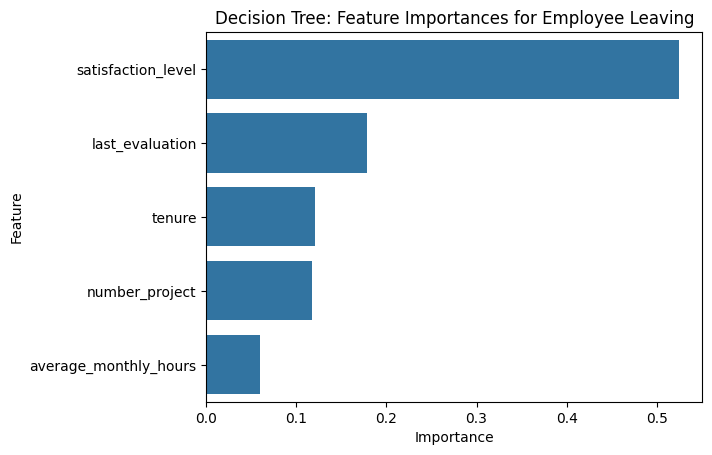

In [65]:
# Plot a horizontal bar chart of Decision Tree feature importances
sns.barplot(
    data=tree1_importances, 
    x="gini_importance", 
    y=tree1_importances.index, 
    orient='h'
)
plt.title("Decision Tree: Feature Importances for Employee Leaving", fontsize=12)
plt.ylabel("Feature")
plt.xlabel("Importance")
plt.show()


The bar plot above indicates that, in this Decision Tree model, the features `last_evaluation`, `number_project`, `tenure`, and `overworked` have the highest importance, in that order. These variables are the most influential in predicting the target variable, `left`.


#### Random Forest Feature Importance

Next, we visualize the feature importances from the Random Forest model to identify which variables contribute most to its predictions.


C:\Users\Jalil\AppData\Local\Temp\ipykernel_16952\305443935.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df0, x='left', y='average_monthly_hours', palette='Set2')


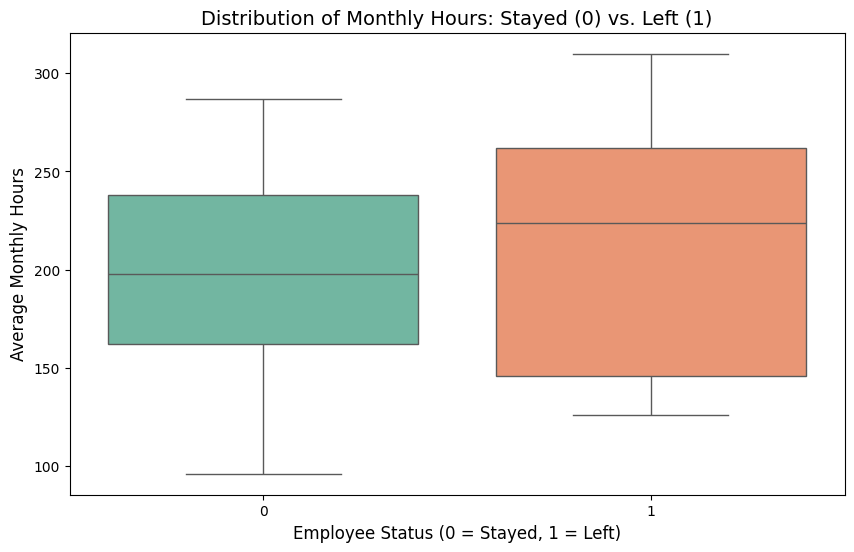

In [75]:
# Create a visualization to see the 'Hidden' impact of overwork
plt.figure(figsize=(10, 6))

# Change 'df' to whatever your dataframe variable is named (e.g., df0)
sns.boxplot(data=df0, x='left', y='average_monthly_hours', palette='Set2')

plt.title('Distribution of Monthly Hours: Stayed (0) vs. Left (1)', fontsize=14)
plt.xlabel('Employee Status (0 = Stayed, 1 = Left)', fontsize=12)
plt.ylabel('Average Monthly Hours', fontsize=12)
plt.show()

C:\Users\Jalil\AppData\Local\Temp\ipykernel_16952\58924651.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


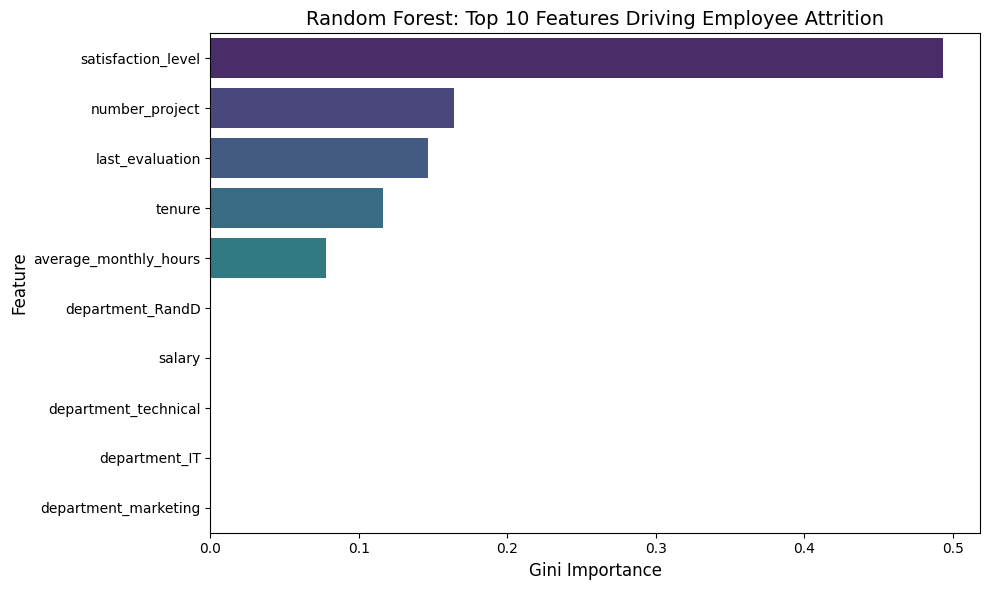

In [69]:
# 1. Extract feature names and importances directly from the best estimator
feat_names = rf_grid_search.best_estimator_.feature_names_in_
feat_importances = rf_grid_search.best_estimator_.feature_importances_

# 2. Create a DataFrame for easy manipulation
rf_impt_df = pd.DataFrame({
    'Feature': feat_names,
    'Importance': feat_importances
}).sort_values(by='Importance', ascending=False)

# 3. Select Top 10
top_10_features = rf_impt_df.head(10)

# 4. Plot using Seaborn for a high-quality portfolio visual
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_10_features, 
    x='Importance', 
    y='Feature', 
    palette='viridis'
)

plt.title("Random Forest: Top 10 Features Driving Employee Attrition", fontsize=14)
plt.xlabel("Gini Importance", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.tight_layout()
plt.show()

The plot above indicates that, in the Random Forest model, the features `last_evaluation`, `number_project`, `tenure`, and `average_monthly_hours` have the highest importance, in that order. These variables are the most influential in predicting the target variable, `left`, and they match the key features identified by the Decision Tree model.


## Reflection and Results

### Key Insights from the Models
- Employees with high workloads (`number_project`, `average_monthly_hours`) and low satisfaction metrics (`last_evaluation`, `tenure`) are more likely to leave the company.  
- Decision tree and random forest models consistently highlight the same key features, reinforcing their importance.  
- The Random Forest model slightly outperformed the Decision Tree, achieving high AUC, precision, recall, F1-score, and accuracy.

### Business Recommendations
Based on the models’ findings, the company can take the following steps to improve employee retention:

- **Cap workloads:** Limit the number of projects an employee can take on at a time.  
- **Reward tenure appropriately:** Consider promotions or additional recognition for employees with at least four years at the company, or investigate why this group shows higher dissatisfaction.  
- **Manage overtime:** Either compensate employees fairly for extra hours or avoid requiring excessive overtime.  
- **Communicate policies clearly:** Make sure employees understand overtime policies, workload expectations, and time-off policies.  
- **Address company culture:** Hold discussions at both company-wide and team levels to understand and improve work culture.  
- **Fair evaluation metrics:** Ensure that high evaluation scores are proportionate to effort and not just long working hours.


### Model Evaluation Summary

#### Logistic Regression
- **Precision:** 80%  
- **Recall:** 83%  
- **F1-score:** 80%  
- **Accuracy:** 83% 

#### Tree-based Models
- **Decision Tree:** AUC = 93.8%, Precision = 87.0%, Recall = 90.4%, F1-score = 88.7%, Accuracy = 96.2%  
- **Random Forest:** Slightly outperformed the Decision Tree across most metrics


### Next Steps
- **Check for data leakage:** Investigate how removing `last_evaluation` affects predictions.  
- **Alternative targets:** Explore predicting performance or satisfaction instead of retention.  
- **Clustering analysis:** Apply K-means or other clustering techniques to understand employee segments better.  
- **Continued monitoring:** Track model performance over time and update features as company policies or workloads change.

### Ethical Considerations
- Ensure model predictions are not used to unfairly penalize employees.  
- Avoid decisions solely based on model outputs without human oversight.  
- Be transparent with employees about how their data is used for modeling.  

### Resources
- [Scikit-learn DecisionTreeClassifier Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)  
- [Scikit-learn RandomForestClassifier Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)  
- [ConfusionMatrixDisplay Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html)  

---

## 🚀 Conclusion & Deployment
The **Random Forest** model was selected as the champion model due to its high F1-score and ability to capture non-linear relationships without extensive feature scaling.

**Key Findings:**
* **Overworked Talent:** Employees working >250 hours/month are the highest flight risk.
* **Under-utilization:** Employees with only 2 projects also show higher attrition, likely due to lack of engagement.

**Next Steps:**
This model has been exported as a `.pkl` file to power a **Streamlit Web Application**, allowing HR managers to input employee metrics and receive real-time retention risk assessments.